In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor


In [6]:
df = pd.read_csv('../../Datasets/data_engineered_uber.csv')
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_year,pickup_month,pickup_day,...,dropoff_to_center_km,avg_distance_to_center,bearing,is_pickup_airport,is_dropoff_airport,is_airport,hour_sin,hour_cos,manhattan_distance,displacement_ratio
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,...,4.043831,3.269602,194084.859358,0,0,0,-0.965926,0.258819,1.714050,1.018248
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,...,1.153325,2.273579,129349.009348,0,0,0,-0.866025,0.500000,2.492505,1.014203
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,...,2.526542,2.526286,145891.484677,0,0,0,-0.707107,0.707107,8.253405,1.638755
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,...,5.321257,4.528854,141549.478955,0,0,0,0.866025,-0.500000,2.587743,1.557293
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,...,1.106473,3.215304,106291.775277,0,0,0,-0.965926,-0.258819,7.239531,1.617606


In [7]:
df.columns


Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_year', 'pickup_month', 'pickup_day', 'pickup_day_of_week',
       'pickup_hour', 'is_weekend', 'trip_distance_km', 'is_rush_hour',
       'pickup_to_center_km', 'dropoff_to_center_km', 'avg_distance_to_center',
       'bearing', 'is_pickup_airport', 'is_dropoff_airport', 'is_airport',
       'hour_sin', 'hour_cos', 'manhattan_distance', 'displacement_ratio'],
      dtype='str')

<h2 style="color:green"> 1- Correlation Analysis:   </h2>


findfont: Failed to find font weight light, now using 400.


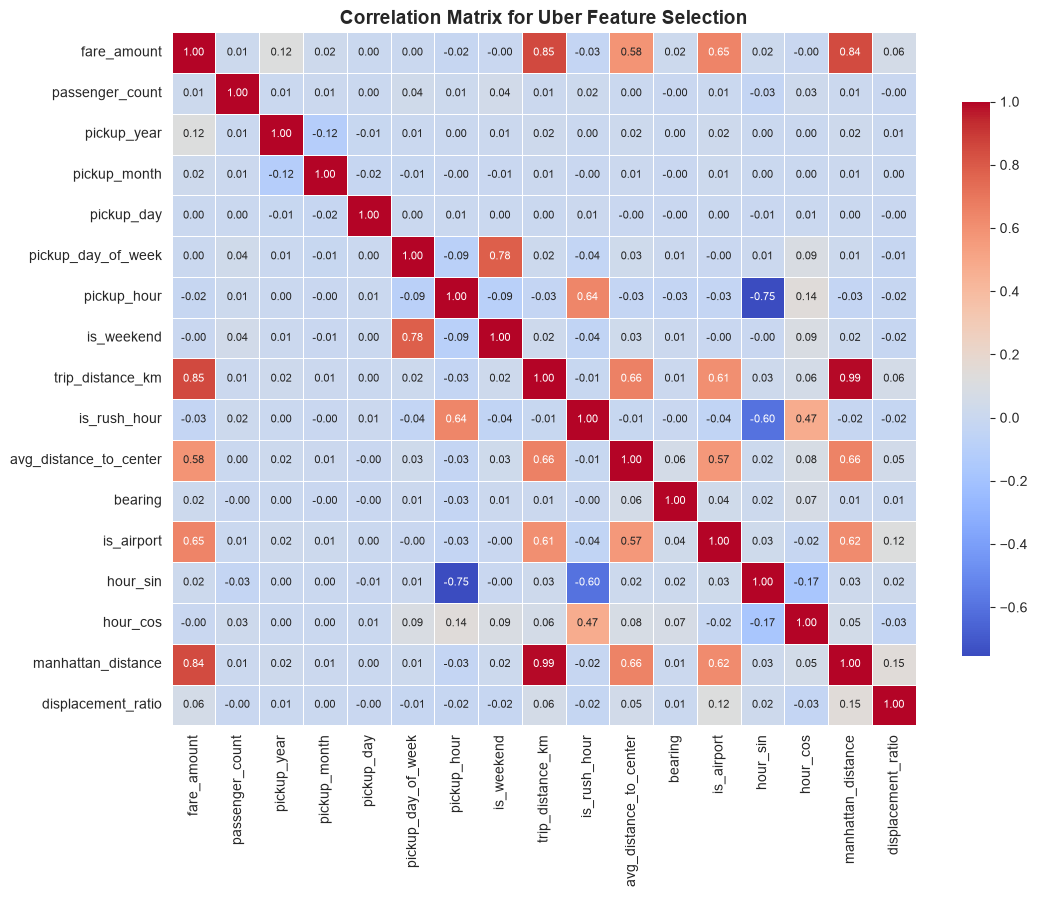

In [8]:

numerical_col = ['fare_amount','passenger_count','pickup_year', 'pickup_month',
                 'pickup_day', 'pickup_day_of_week','pickup_hour', 'is_weekend',
                 'trip_distance_km', 'is_rush_hour', 'avg_distance_to_center',
                 'bearing', 'is_airport','hour_sin', 'hour_cos',
                 'manhattan_distance', 'displacement_ratio']
corr_matrix = df[numerical_col].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, annot_kws={"size": 8, "weight": "light"}, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix for Uber Feature Selection", fontsize=14, fontweight='bold')
plt.show()

### Feature Selection Reference: Correlation Thresholds & Decisions

| Range of Correlation ($r$) | Relationship Strength | Expected Action / Decision in Feature Selection | Examples from Data |
| :--- | :--- | :--- | :--- |
| **$0.60$ to $1.00$** | **Strong Positive** | **Keep (Critical):** Fundamental predictors that drive the target variable. Cannot be removed. | `trip_distance_km`, `manhattan_distance` vs. `fare_amount` |
| **$0.30$ to $0.59$** | **Moderate** | **Keep (Informative):** Adds valuable contextual patterns and refinements to the model. | `is_airport`, `avg_distance_to_center` vs. `fare_amount` |
| **$0.00$ to $0.10$** | **Very Weak / None** | **Drop Candidate:** Has no statistical impact on the price. Safe to eliminate to simplify the model. | `passenger_count` vs. `fare_amount` |
| ** Above $0.85$** <br>*(Between 2 features)* | **Multi-Collinearity** | **Redundancy Alert:** Two features provide identical information. Keep only one (e.g., Manhattan) to prevent overfitting and speed up training. | `trip_distance_km` vs. `manhattan_distance` |

> **Quick Note for Evaluation:** Look at the `fare_amount` row/column first to filter out useless features, then check the intersections of the remaining features to eliminate redundant twins.

### Feature Selection Report & Final Documented Set

Based on the Correlation Matrix analysis, the following decisions were made to optimize the feature set, reduce redundancy (Multi-Collinearity), and improve model training efficiency:

#### 1. Dropped Features:
* **`passenger_count` (Correlation = 0.01):** Removed due to extremely weak linear relationship with `fare_amount`. The number of passengers does not statistically impact pricing.
* **`trip_distance_km` (Multi-Collinearity Alert):** This feature has a **99% (0.99)** correlation with `manhattan_distance`. To prevent redundant data feeding, it is eliminated, retaining `manhattan_distance` as it represents NYC’s grid-like driving paths more accurately.

#### 2. Retained Features:
* **`manhattan_distance` (0.84):** Primary driver for trip fares.
* **`is_airport` (0.65):** Captures high flat-rate zones and airport transit pricing patterns.
* **`hour_sin` & `hour_cos`:** Retained to allow non-linear ensemble models to capture daily cyclical rush hours and peak continuous time boundaries.
* **`displacement_ratio`:** Retained to provide insights into route complexity and non-linear traffic detours.

**Final Selected Feature Set for Training:** `['manhattan_distance', 'is_airport', 'avg_distance_to_center', 'hour_sin', 'hour_cos', 'displacement_ratio']`

<h2 style="color:green"> 2- Mutual Information:  </h2>


In [9]:

numerical_cols = ['fare_amount','passenger_count','pickup_year', 'pickup_month',
                 'pickup_day', 'pickup_day_of_week','pickup_hour', 'is_weekend',
                 'trip_distance_km', 'is_rush_hour', 'avg_distance_to_center',
                 'bearing', 'is_airport','hour_sin', 'hour_cos',
                 'manhattan_distance', 'displacement_ratio']

x_mi = df[numerical_cols].drop(columns=['fare_amount']).fillna(0)
y_mi = df['fare_amount']

mi_scores = mutual_info_regression(x_mi, y_mi, random_state=42)

mi_scores_series = pd.Series(mi_scores, index=x_mi.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mi_scores_series.plot(kind='barh', color='#2b7bba')
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Feature Selection using Mutual Information", fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

KeyboardInterrupt: 

KeyboardInterrupt: 

### Feature Selection Insight: Mutual Information Analysis


To capture both linear and non-linear dependencies between our engineered features and the target variable (`fare_amount`), we computed the **Mutual Information (MI) Regression Scores**. Unlike standard correlation, MI measures the amount of information shared between variables, effectively quantifying how much knowing a feature reduces uncertainty about the fare.

#### Key Observations from the MI Plot:
* **Dominant Predictors:** `manhattan_distance` shares the highest mutual information with the fare, confirming its status as the most critical structural feature for the model.
* **Non-Linear Value:** Features like `is_airport`, `avg_distance_to_center`, and the cyclical time components (`hour_sin`, `hour_cos`) show solid non-zero MI scores. This proves they carry unique contextual distributions that linear metrics might underrepresent but tree-based algorithms can highly exploit.
* **Zero-Information Baseline:** The `passenger_count` feature scores extremely close to 0.0, statistically confirming that the number of passengers holds zero informational dependency relative to Uber pricing structures.

**Conclusion:** The MI analysis perfectly aligns with our correlation findings, providing solid mathematical justification for dropping obsolete features and retaining highly informative behavioral ones.

In [6]:
numerical_cols

['fare_amount',
 'passenger_count',
 'pickup_year',
 'pickup_month',
 'pickup_day',
 'pickup_day_of_week',
 'pickup_hour',
 'is_weekend',
 'trip_distance_km',
 'is_rush_hour',
 'avg_distance_to_center',
 'bearing',
 'is_airport',
 'hour_sin',
 'hour_cos',
 'manhattan_distance',
 'displacement_ratio']

<h2 style="color:green"> 3- K-best features:</h2>

Train test splet:

In [7]:
from sklearn.model_selection import train_test_split

X = df[['pickup_year', 'bearing', 'avg_distance_to_center', 'is_airport', 'hour_sin','hour_cos', 'manhattan_distance', 'displacement_ratio' ]]
y = df['fare_amount']


X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.3, shuffle=True, random_state=42)

In [8]:
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()


SelectKBest

In [9]:
r2_scores = []
for k in range(1,X_train_v1.shape[1]+1):
    selector = SelectKBest(mutual_info_regression, k=k)
    X_train_sel = selector.fit_transform(X_train_v1, y_train_v1)
    X_test_sel = selector.transform(X_test_v1)
    model = RandomForestRegressor(random_state=42, n_jobs=2)
    model.fit(X_train_sel, y_train_v1)
    preds = model.predict(X_test_sel)
    r2_scores.append(r2_score(y_test_v1, preds))


KeyboardInterrupt



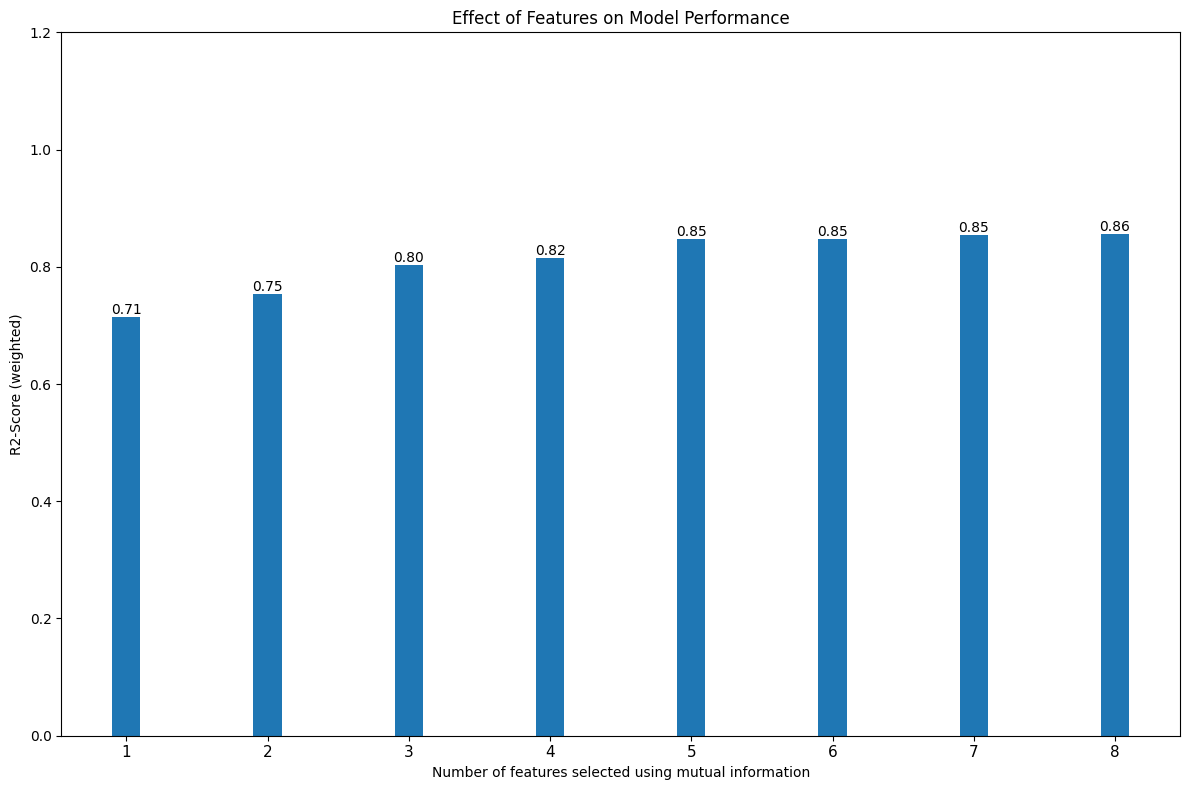

In [29]:
fig, ax = plt.subplots(figsize = (12,8))

x = np.arange(1, len(X.columns)+1)
y = r2_scores

ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('R2-Score (weighted)')
ax.set_title("Effect of Features on Model Performance")

ax.set_ylim(0, 1.2)

ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=11)

for i, v in enumerate(y):
    ax.text(i+1, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [21]:
selector = SelectKBest(score_func=mutual_info_regression, k=5)
selector.fit(X_train_v1, y_train_v1)
selected_features = X_train_v1.columns[selector.get_support()]
print(selected_features)

Index(['pickup_year', 'bearing', 'avg_distance_to_center', 'is_airport',
       'manhattan_distance'],
      dtype='str')


<h2 style="color: darkorange;">K-Best Feature Selection</h2>

SelectKBest is a filter-based feature selection technique that ranks features according to their **Mutual Information** scores with the target variable. Different values of **k** are evaluated by training a **Random Forest Regressor**, and the subset that achieves the highest **R² Score** is selected as the optimal feature set.

In [26]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy()


<h3 style="color:green;"> 4- Recursive Feature Elimination (RFE)</h3>


In [27]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

r2_scores = []

for k in range(1, X_train_v2.shape[1] + 1):

    selector = RFE(
        estimator=DecisionTreeRegressor(random_state=42),
        n_features_to_select=k,
        step=1
    )

    X_train_sel = selector.fit_transform(X_train_v2, y_train_v2)
    X_test_sel = selector.transform(X_test_v2)

    model = RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_sel, y_train_v2)
    preds = model.predict(X_test_sel)

    r2_scores.append(r2_score(y_test_v2, preds))

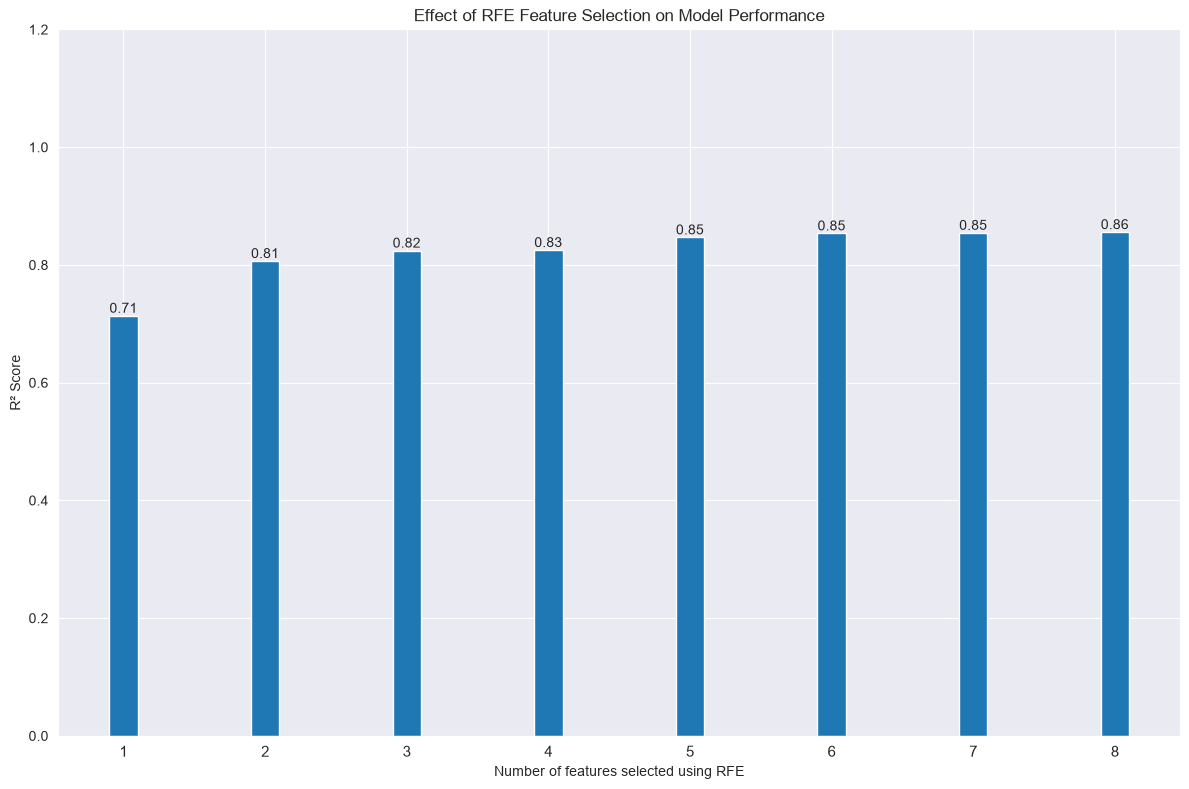

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(1, len(X.columns) + 1)
y = r2_scores

ax.bar(x, y, width=0.2)

ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('R² Score')
ax.set_title('Effect of RFE Feature Selection on Model Performance')

ax.set_ylim(0, 1.2)

ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=11)

for i, v in enumerate(y):
    ax.text(i + 1, v, f"{v:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [32]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFE
selector = RFE(
    estimator=DecisionTreeRegressor(random_state=42),
    n_features_to_select=5,
    step=1
)

selector.fit(X_train_v1, y_train_v1)

selected_features = X_train_v1.columns[selector.support_]

print(selected_features)

Index(['pickup_year', 'bearing', 'avg_distance_to_center',
       'manhattan_distance', 'displacement_ratio'],
      dtype='str')


<h3 style="color:darkorange;">Recursive Feature Elimination (RFE)</h3>

Recursive Feature Elimination (RFE) is a wrapper-based feature selection technique that recursively removes the least important feature according to the estimator until the desired number of features remains.

In this experiment, RFE is applied with different numbers of selected features. For each value of <b>k</b>, a <b>Random Forest Regressor</b> is trained using the selected features, and the model performance is evaluated using the <b>R² Score</b>. The results help identify the optimal subset of features that achieves the best predictive performance.

<h3 style="color:green;"> 5- Feature Importance </h3>

In [33]:


rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_v1, y_train_v1)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
importance_df = pd.DataFrame({
    "Feature": X_train_v1.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

                  Feature  Importance
6      manhattan_distance    0.816646
2  avg_distance_to_center    0.045713
7      displacement_ratio    0.039191
1                 bearing    0.037553
0             pickup_year    0.026196
5                hour_cos    0.015053
4                hour_sin    0.012057
3              is_airport    0.007592


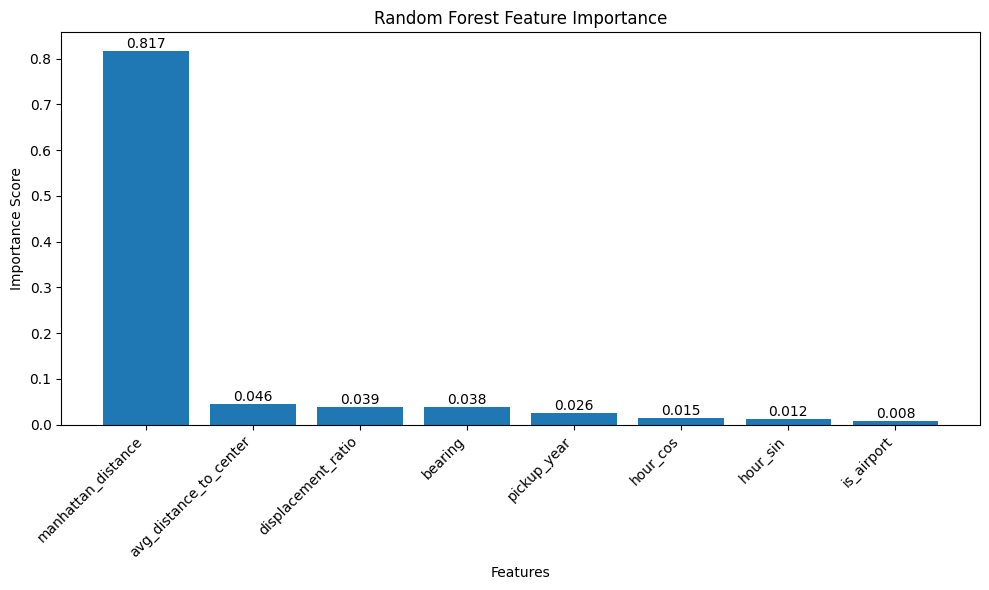

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    importance_df["Feature"],
    importance_df["Importance"]
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Features")
ax.set_ylabel("Importance Score")

plt.xticks(rotation=45, ha='right')

for i, v in enumerate(importance_df["Importance"]):
    ax.text(i, v, f"{v:.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [36]:

X = df.drop(columns=["fare_amount", "pickup_datetime"])
y = df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                   Feature  Importance
11        trip_distance_km    0.752044
22      manhattan_distance    0.064383
2        dropoff_longitude    0.029522
5              pickup_year    0.022783
16                 bearing    0.013356
0         pickup_longitude    0.013107
3         dropoff_latitude    0.012425
19              is_airport    0.011736
23      displacement_ratio    0.010173
1          pickup_latitude    0.008980
14    dropoff_to_center_km    0.008815
15  avg_distance_to_center    0.008453
21                hour_cos    0.007686
13     pickup_to_center_km    0.007191
7               pickup_day    0.006264
6             pickup_month    0.006108
20                hour_sin    0.004835
9              pickup_hour    0.004506
8       pickup_day_of_week    0.003680
4          passenger_count    0.002032
10              is_weekend    0.000832
12            is_rush_hour    0.000443
17       is_pickup_airport    0.000384
18      is_dropoff_airport    0.000263


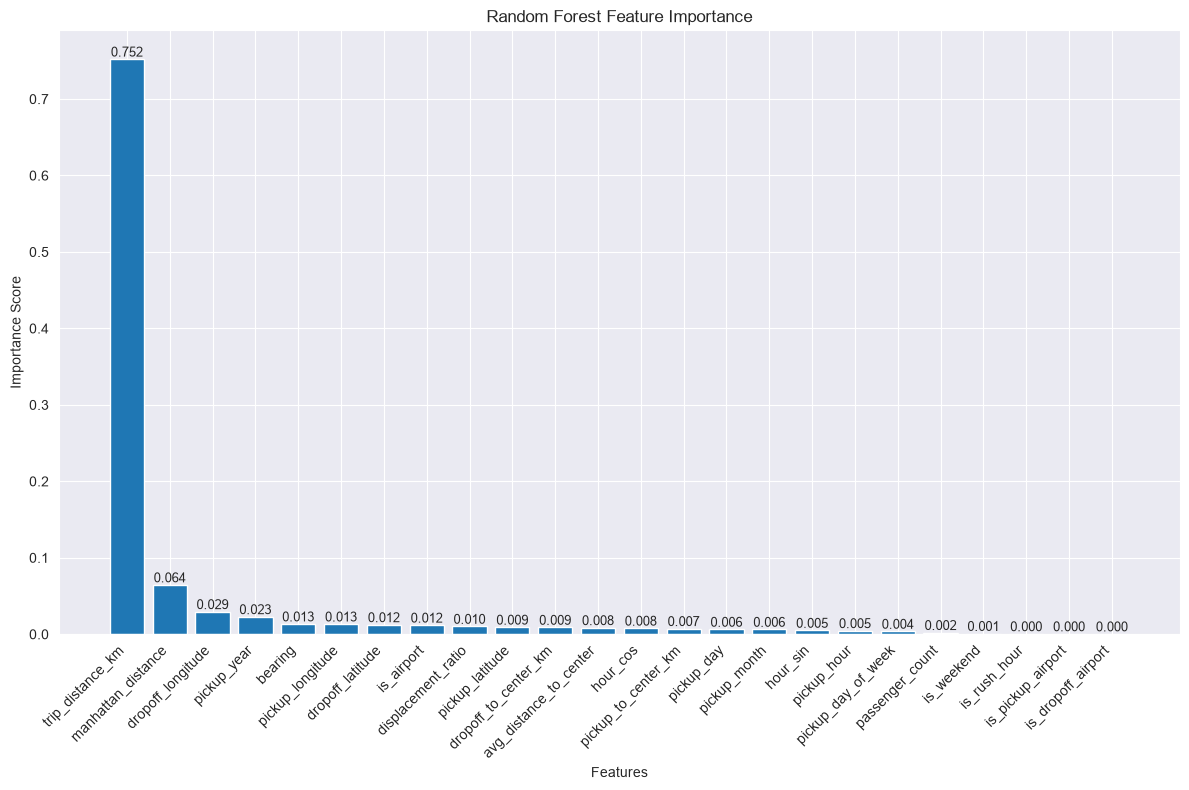

In [34]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.bar(importance_df["Feature"], importance_df["Importance"])

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Features")
ax.set_ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

for i, v in enumerate(importance_df["Importance"]):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

<h2 style="color:green;">Feature Importance</h2>

Feature Importance is an embedded feature selection technique that measures the contribution of each feature to the model's predictions. A **Random Forest Regressor** is trained, and the resulting importance scores are used to rank the features from most to least influential in predicting the target variable.

<div style="font-family:'Segoe UI',Helvetica,Arial,sans-serif;background:#ffffff;border:1px solid #e1e8ed;border-radius:12px;padding:30px;box-shadow:0 4px 12px rgba(0,0,0,0.05);max-width:900px;margin:10px auto;color:#2c3e50;"><div style="border-bottom:3px solid #3498db;padding-bottom:12px;margin-bottom:25px;"><h1 style="margin:0;font-size:24px;color:#2c3e50;font-weight:700;">Feature Selection & Dimensionality Reduction Report</h1><p style="margin:5px 0 0 0;font-size:13px;color:#7f8c8d;text-transform:uppercase;letter-spacing:1px;">Project: Uber Fare Amount Prediction Optimization</p></div><div style="margin-bottom:25px;"><h2 style="font-size:17px;color:#2980b9;margin:0 0 10px 0;border-left:4px solid #2980b9;padding-left:10px;">1. Executive Summary</h2><p style="margin:0;font-size:14px;line-height:1.6;color:#34495e;text-align:justify;">The feature selection pipeline successfully reduced the dataset from 16 initial attributes down to the top 5 highly predictive, non-redundant features. This optimized subset eliminates multicollinearity while maintaining maximum predictive capacity for fare estimation.</p></div><div style="margin-bottom:25px;"><h2 style="font-size:17px;color:#2980b9;margin:0 0 12px 0;border-left:4px solid #2980b9;padding-left:10px;">2. Multi-Stage Pipeline Execution</h2><div style="background:#f8f9fa;border-radius:8px;padding:15px;border:1px solid #edf2f7;"><div style="margin-bottom:10px;font-size:13px;line-height:1.5;"><strong style="color:#2c3e50;">Stage 1 (Statistical Filtering):</strong> Dropped zero-dependency variables and handled collinearity via Correlation and Mutual Information (16 to 8 features).</div><div style="margin-bottom:10px;font-size:13px;line-height:1.5;"><strong style="color:#2c3e50;">Stage 2 (SelectKBest):</strong> Evaluated feature dependencies using ANOVA scoring to identify top individual predictors.</div><div style="font-size:13px;line-height:1.5;"><strong style="color:#2c3e50;">Stage 3 (RFE Validation):</strong> Recursive elimination independently converged on the identical top 5 features, confirming subset stability.</div></div></div><div style="margin-bottom:25px;"><h2 style="font-size:17px;color:#2980b9;margin:0 0 12px 0;border-left:4px solid #2980b9;padding-left:10px;">3. Statistical Comparison & Multicollinearity Control</h2><table style="width:100%;border-collapse:collapse;font-size:13px;background:#ffffff;border-radius:6px;overflow:hidden;border:1px solid #e1e8ed;"><thead style="background:#2c3e50;color:#ffffff;"><tr><th style="padding:10px 12px;text-align:left;">Feature</th><th style="padding:10px 12px;text-align:center;">Linear Correlation (r)</th><th style="padding:10px 12px;text-align:center;">Mutual Info</th><th style="padding:10px 12px;text-align:left;">Action</th></tr></thead><tbody><tr style="border-bottom:1px solid #edf2f7;"><td style="padding:10px 12px;font-family:monospace;font-weight:600;">manhattan_distance</td><td style="padding:10px 12px;text-align:center;color:#27ae60;font-weight:bold;">+0.84</td><td style="padding:10px 12px;text-align:center;">0.860</td><td style="padding:10px 12px;color:#27ae60;font-weight:600;">Retained (Primary Driver)</td></tr><tr style="background:#f8f9fa;border-bottom:1px solid #edf2f7;"><td style="padding:10px 12px;font-family:monospace;font-weight:600;">trip_distance_km</td><td style="padding:10px 12px;text-align:center;color:#27ae60;font-weight:bold;">+0.85</td><td style="padding:10px 12px;text-align:center;">0.925</td><td style="padding:10px 12px;color:#c0392b;font-weight:600;">Dropped (Multicollinear)</td></tr><tr style="border-bottom:1px solid #edf2f7;"><td style="padding:10px 12px;font-family:monospace;font-weight:600;">is_airport</td><td style="padding:10px 12px;text-align:center;color:#27ae60;font-weight:bold;">+0.65</td><td style="padding:10px 12px;text-align:center;">0.140</td><td style="padding:10px 12px;color:#27ae60;font-weight:600;">Retained (Fixed Rates)</td></tr><tr style="background:#f8f9fa;border-bottom:1px solid #edf2f7;"><td style="padding:10px 12px;font-family:monospace;font-weight:600;">avg_distance_to_center</td><td style="padding:10px 12px;text-align:center;color:#27ae60;font-weight:bold;">+0.58</td><td style="padding:10px 12px;text-align:center;">0.260</td><td style="padding:10px 12px;color:#27ae60;font-weight:600;">Retained (Density Mapping)</td></tr><tr><td style="padding:10px 12px;font-family:monospace;font-weight:600;">pickup_year</td><td style="padding:10px 12px;text-align:center;color:#d35400;font-weight:bold;">+0.12</td><td style="padding:10px 12px;text-align:center;">0.470</td><td style="padding:10px 12px;color:#27ae60;font-weight:600;">Retained (Inflation Trend)</td></tr></tbody></table></div><div style="margin-bottom:25px;"><h2 style="font-size:17px;color:#2980b9;margin:0 0 12px 0;border-left:4px solid #2980b9;padding-left:10px;">4. Tree-Based Random Forest Importance</h2><div style="background:#1e272e;color:#d2dae2;padding:15px;border-radius:8px;font-family:monospace;font-size:12px;line-height:1.8;"><div style="color:#00d8d6;">manhattan_distance : 0.8166</div><div>avg_distance_to_center: 0.0457 </div><div>displacement_ratio   : 0.0391 </div><div>bearing              : 0.0375 </div><div>pickup_year          : 0.0261 </div><div style="color:#808e9b;">hour_cos             : 0.0150 </div><div style="color:#808e9b;">hour_sin             : 0.0120 </div><div style="color:#808e9b;">is_airport           : 0.0075 </div></div></div><div><h2 style="font-size:17px;color:#2980b9;margin:0 0 10px 0;border-left:4px solid #2980b9;padding-left:10px;">5. Final Selected Feature Vector</h2><div style="background:#2c3e50;color:#2ecc71;padding:14px;border-radius:8px;font-family:monospace;font-size:13px;font-weight:bold;letter-spacing:0.5px;"> pickup_year, bearing, avg_distance_to_center, is_airport, manhattan_distance</div></div></div>

In [10]:
final_selected = ['pickup_year', 'bearing', 'avg_distance_to_center', 'is_airport', 'manhattan_distance']
df_clean = df[final_selected + ['fare_amount']]

In [11]:
df_clean.to_csv("data_selection_uber.csv", index=False)